# 从零手写 Transformer —— 逐模块精讲与实现

> **目标**：不调用任何官方高层组件（`nn.Transformer`、`nn.MultiheadAttention`、`nn.LayerNorm`、`F.scaled_dot_product_attention` 等），
> 只用 PyTorch 的 **tensor 运算 + `nn.Linear` / `nn.Parameter` / `nn.Dropout`** 等基础积木，
> 从零拼装出完整的 Transformer，并且每个模块都与官方实现做**数值对照验证**，确保手写的没错。

## 整体数据流

![transformer_dataflow](../src/transformer1.png)

## 学习路线（每章 = 动机 → 原理公式 → 手写实现 → Demo 验证）

| 章节 | 模块 | 一句话说明 |
|---|---|---|
| 1 | Embedding | token 整数 → 稠密向量（本质是查表） |
| 2 | PositionalEncoding | 注入位置信息，弥补注意力的"无序性" |
| 3 | softmax / SDPA / Mask | 注意力的三块地基 |
| 4 | MultiHeadAttention | 多个子空间并行地"看"序列 |
| 5 | FFN | 逐位置两层 MLP，注意力之外的特征加工厂 |
| 6 | LayerNorm | 稳定训练的归一化层 |
| 7 | 残差连接实验 | 用梯度范数实测残差的价值 |
| 8 | Encoder | 编码器层与编码器堆叠 |
| 9 | Decoder | 掩码自注意力 + 交叉注意力 + FFN |
| 10 | Transformer | 总装完整模型 |
| 11 | 复制任务实战 | 训练 + 贪心解码 + 可视化 |
| 12 | 总结 | 要点回顾与延伸方向 |

## 形状记号约定

`B`=batch 大小，`L`=序列长度，`d_model`=模型维度，`H`=注意力头数，`d_k`=每头维度（`d_k = d_model / H`），`V`=词表大小。


In [1]:
# ========== 环境自检 ==========
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)   # 全局随机种子，保证结果可复现
print(f"PyTorch 版本: {torch.__version__} | 计算设备: {torch.device('cpu')}")

# 简易测试计数器：后续每个模块都用它做"官方对照"验证
PASS, FAIL = 0, 0
def check(name, cond, extra=""):
    global PASS, FAIL
    if cond:
        PASS += 1
        print(f"[PASS] {name} {extra}")
    else:
        FAIL += 1
        print(f"[FAIL] {name} {extra}")

print("环境就绪，测试工具 check() 已就位。")

PyTorch 版本: 2.12.0+cpu | 计算设备: cpu
环境就绪，测试工具 check() 已就位。


## 1. 词嵌入 Embedding：token 如何变成向量

**动机**：神经网络做的是矩阵运算，吃不了 `"猫"` 这个词，甚至吃不了整数 id `7` 本身。
最朴素的想法是 one-hot 向量，但词表一大就极度稀疏、维度爆炸。

词嵌入的等价形式是一个**可学习矩阵** $\mathbf{E} \in \mathbb{R}^{V \times d_{model}}$，
`forward` 只做一件事：**按行查表**。

$$\text{Embedding}(\text{id}) = \mathbf{E}[\text{id}]$$

**实现要点**
- 权重 `weight` 形状 `(vocab_size, d_model)`，就是一个 `nn.Parameter`；
- `forward(ids)` 用高级索引 `self.weight[ids]` 完成 `(B, L) → (B, L, d_model)`；
- 它与 `one_hot(ids) @ E` 在**数学上完全等价**（下面会验证），但查表只取需要的行，比矩阵乘法快得多；
- 嵌入是**可学习**的：训练后语义相近的 token，其向量会自然靠近。

In [12]:
# ========== 手写 Embedding ==========
class Embedding(nn.Module):
    """从零实现的词嵌入层（查表操作）"""
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        # 可学习权重：每行是一个 token 的向量
        self.weight = nn.Parameter(torch.randn(vocab_size, d_model))

    def forward(self, ids):
        # ids: (B, L) 整数 -> (B, L, d_model)，weight[ids] 就是按行查表
        return self.weight[ids]

In [13]:
# ========== Demo：与官方 nn.Embedding 及 one-hot 等价性对照 ==========
emb = Embedding(13, 16)
ref = nn.Embedding(13, 16)
with torch.no_grad():
    ref.weight.copy_(emb.weight)      # 拷贝相同权重，保证可比

ids = torch.randint(0, 13, (2, 5))
print("ids:\n", ids)
print("emb(ids).shape:", tuple(emb(ids).shape))

check("Embedding == nn.Embedding", torch.allclose(emb(ids), ref(ids)))
check("Embedding == one-hot @ E", torch.allclose(emb(ids), F.one_hot(ids, 13).float() @ emb.weight))

print("结论：手写查表 与 one-hot 矩阵乘法结果完全一致 —— 嵌入层的本质就是『可学习的查找表』。")


ids:
 tensor([[ 2,  9,  4,  0,  8],
        [12,  9,  6,  7,  2]])
emb(ids).shape: (2, 5, 16)
[PASS] Embedding == nn.Embedding 
[PASS] Embedding == one-hot @ E 
结论：手写查表 与 one-hot 矩阵乘法结果完全一致 —— 嵌入层的本质就是『可学习的查找表』。


## 2. 位置编码 Positional Encoding：让模型知道"谁在前谁在后"

**动机**：自注意力对输入是**置换等变**的——把输入序列打乱，输出只是跟着同样打乱，模型完全感知不到词序。
"猫咬狗"和"狗咬猫"会得到一模一样的表示。因此必须**显式注入位置信息**：在嵌入向量上叠加一个只与位置有关的向量。

$$PE_{(pos,\,2i)} = \sin\!\Big(\frac{pos}{10000^{2i/d_{model}}}\Big), \qquad
PE_{(pos,\,2i+1)} = \cos\!\Big(\frac{pos}{10000^{2i/d_{model}}}\Big)$$

**为什么用 sin/cos？**
- 值域恒在 $[-1,1]$，数值稳定，不会随句子变长而爆炸；
- 不同维度对应**不同波长**（从 $2\pi$ 到 $10000\cdot2\pi$），像"多指针时钟"：低维指针转得快（区分相邻位置），高维指针转得慢（区分远距离位置）；
- 对任意更长序列可以**平滑外推**（直接按公式算即可）；
- 由三角恒等式，$PE_{pos+k}$ 可以表示为 $PE_{pos}$ 的线性变换，便于模型学**相对位置**关系。

**实现要点**
- `register_buffer('pe', ...)`：`pe` 不是参数、**不参与训练**，但会随模型 `state_dict` 一起保存/迁移；
- `div_term` 推导：$10000^{2i/d} = e^{\ln(10000)\cdot 2i/d}$，所以用 `torch.exp(arange(0,d,2) * (-ln(10000)/d))` 一次算出所有分母；
- 偶数维放 sin、奇数维放 cos，`forward` 里 `x + pe[:, :L]`（切片到当前序列长度）后再过 dropout。

In [14]:
# ========== 手写正弦-余弦位置编码 ==========
class PositionalEncoding(nn.Module):
    """正弦-余弦位置编码 (Vaswani et al., 2017)"""
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)                                    # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)   # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))                # 即 10000^(2i/d_model)
        pe[:, 0::2] = torch.sin(position * div_term)                          # 偶数维用 sin
        pe[:, 1::2] = torch.cos(position * div_term)                          # 奇数维用 cos
        self.register_buffer('pe', pe.unsqueeze(0))                           # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, L, d_model)，广播加上前 L 个位置的编码
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [17]:
# ========== Demo：性质验证 ==========
pe_mod = PositionalEncoding(16, max_len=64, dropout=0.0)

check("PE 位置0: sin=0, cos=1",
      torch.allclose(pe_mod.pe[0, 0, 0::2], torch.zeros(8), atol=1e-6)
      and torch.allclose(pe_mod.pe[0, 0, 1::2], torch.ones(8), atol=1e-6))
check("PE 值域 [-1,1]", (pe_mod.pe.abs() <= 1.0).all().item())
x_tmp = torch.randn(2, 10, 16)
check("PE forward shape", pe_mod(x_tmp).shape == (2, 10, 16))

[PASS] PE 位置0: sin=0, cos=1 
[PASS] PE 值域 [-1,1] 
[PASS] PE forward shape 


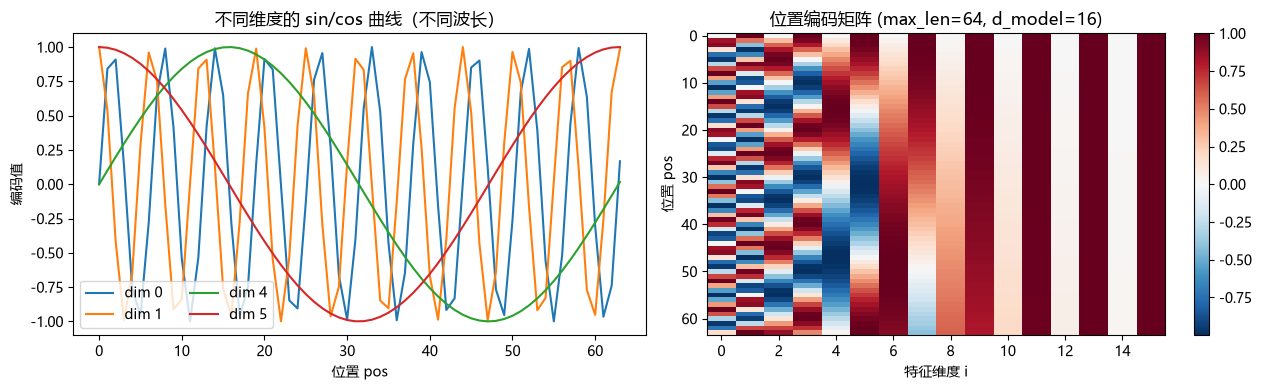

In [16]:
# ========== 可视化：不同维度的"指针"转速 ==========
import matplotlib
import matplotlib.pyplot as plt
# 中文字体（按可用性依次回退）
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for d in [0, 1, 4, 5]:                       # 低维波长短（转得快），高维波长长（转得慢）
    axes[0].plot(pe_mod.pe[0, :64, d].numpy(), label=f"dim {d}")
axes[0].set_title("不同维度的 sin/cos 曲线（不同波长）")
axes[0].set_xlabel("位置 pos"); axes[0].set_ylabel("编码值"); axes[0].legend(ncol=2)

im = axes[1].imshow(pe_mod.pe[0].numpy(), aspect='auto', cmap='RdBu_r')
axes[1].set_title("位置编码矩阵 (max_len=64, d_model=16)")
axes[1].set_xlabel("特征维度 i"); axes[1].set_ylabel("位置 pos")
fig.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

## 3. 注意力的三块地基：softmax、缩放点积注意力、Mask

### 3.1 softmax 与数值稳定性

softmax 把任意实数得分变成概率分布：

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**关键技巧：先减去最大值**。因为 $e^{x-c}$ 对所有分量同乘 $e^{-c}$，分子分母约掉，**结果不变**，
但能防止 $e^{x}$ 上溢（fp32 下 `exp(709)` 就会溢出为 `inf`，`inf/inf = NaN`）。下面会用一个反例验证朴素实现确实会 NaN。

### 3.2 缩放点积注意力

$$\text{Attention}(Q, K, V) = \text{softmax}\!\Big(\frac{QK^{\top}}{\sqrt{d_k}}\Big)V$$

- $QK^\top$：每个 query 与所有 key 做点积，得到"相关度得分" $(L_q, L_k)$；
- **为什么除以 $\sqrt{d_k}$**：点积是 $d_k$ 个乘积之和，维度越大方差越大（$\propto d_k$），
  得分一大 softmax 就进入饱和区（输出接近 one-hot），梯度趋近 0。除以 $\sqrt{d_k}$ 把方差拉回 1 的量级；
- $V$ 加权求和：相关度越高的位置，其 value 贡献越大。

### 3.3 Mask：决定"能看谁"

mask 是**可广播到 $(B, H, L_q, L_k)$ 的 bool 张量**，`True`=允许 attend，`False`=禁止。
实现上用 `masked_fill(~mask, -inf)` 把禁止位置的得分设为 $-\infty$，softmax 后其权重**严格为 0**
（不能把得分设成 0 分——那样它仍会分走概率质量）。

| mask | 形状 | 语义 |
|---|---|---|
| padding mask | `(B, 1, 1, L)` | 屏蔽 PAD，批内变长序列对齐 |
| causal mask | `(1, 1, L, L)` | 下三角：位置 $t$ 只能看 $\le t$ 的位置，自回归生成必需 |
| 两者按位与 | `(B, 1, L, L)` | 解码器实际使用（既防偷看未来，又防看 PAD） |

In [18]:
# ========== 手写数值稳定 softmax ==========
def softmax(x, dim=-1):
    """数值稳定的 softmax：先减去最大值，防止 exp 上溢"""
    x = x - x.max(dim=dim, keepdim=True).values
    e = torch.exp(x)
    return e / e.sum(dim=dim, keepdim=True)

# ---- 验证 ----
s = torch.randn(3, 7) * 3
check("softmax == F.softmax", torch.allclose(softmax(s), F.softmax(s, -1)))

big = s + 1000.0   # fp32 下加 1000 有舍入误差，放宽容差；关键是结果有限、不 NaN
stable = softmax(big)
check("softmax 数值稳定(x+1000): 有限值且接近 F.softmax",
      torch.isfinite(stable).all().item() and torch.allclose(stable, F.softmax(s, -1), atol=1e-3))

naive = torch.exp(s + 1000.0); naive = naive / naive.sum(-1, keepdim=True)   # 不减 max 的朴素实现
check("朴素 softmax 上溢产生 NaN (反例)", torch.isnan(naive).any().item())

[PASS] softmax == F.softmax 
[PASS] softmax 数值稳定(x+1000): 有限值且接近 F.softmax 
[PASS] 朴素 softmax 上溢产生 NaN (反例) 


In [19]:
# ========== 手写 mask 工具 + 缩放点积注意力 ==========
def make_padding_mask(ids, pad_id=0):
    """(B, L) -> (B, 1, 1, L)  True=真实 token（允许被 attend）"""
    return (ids != pad_id).unsqueeze(1).unsqueeze(2)

def make_causal_mask(L, device=None):
    """(1, 1, L, L) 下三角 True：位置 t 只能看到 <= t 的位置"""
    m = torch.tril(torch.ones(L, L, dtype=torch.bool, device=device))
    return m.unsqueeze(0).unsqueeze(0)

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (B, H, Lq, d_k)  K/V: (B, H, Lk, d_k)
    mask: 可广播到 (B, H, Lq, Lk) 的 bool 张量, True=允许 attend
    返回: 输出 (B, H, Lq, d_k), 注意力权重 (B, H, Lq, Lk)
    """
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)      # (B, H, Lq, Lk)
    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))  # 不允许的位置设为 -inf
    attn = softmax(scores, dim=-1)                         # 每行和为 1
    return attn @ V, attn

In [20]:
# ========== Demo：无 mask 的缩放点积注意力 ==========
B, H, Lq, Lk, dk = 2, 3, 5, 7, 16
Q, K, V = torch.randn(B, H, Lq, dk), torch.randn(B, H, Lk, dk), torch.randn(B, H, Lk, dk)

out, attn = scaled_dot_product_attention(Q, K, V)
check("SDPA 输出 == attn @ V", torch.allclose(out, attn @ V))
check("SDPA 权重每行和=1", torch.allclose(attn.sum(-1), torch.ones(B, H, Lq)))
check("SDPA == F.scaled_dot_product_attention",
      torch.allclose(out, F.scaled_dot_product_attention(Q, K, V), atol=1e-6))

print("attn[0,0]（第 0 个样本第 0 个头，行=query 位置，列=key 位置，每行和为 1）:")
print(attn[0, 0].detach().numpy().round(3))

[PASS] SDPA 输出 == attn @ V 
[PASS] SDPA 权重每行和=1 
[PASS] SDPA == F.scaled_dot_product_attention 
attn[0,0]（第 0 个样本第 0 个头，行=query 位置，列=key 位置，每行和为 1）:
[[0.076 0.198 0.055 0.181 0.181 0.216 0.094]
 [0.18  0.085 0.101 0.178 0.299 0.115 0.043]
 [0.31  0.021 0.216 0.119 0.178 0.064 0.092]
 [0.116 0.382 0.095 0.151 0.034 0.134 0.088]
 [0.102 0.117 0.147 0.251 0.175 0.13  0.078]]


In [21]:
# ========== Demo：causal mask（自回归"防偷看"） ==========
cmask = make_causal_mask(Lq)
print("causal mask（True=允许），下三角结构：")
print(cmask[0, 0].numpy().astype(int))

out_c, attn_c = scaled_dot_product_attention(Q, K[:, :, :Lq], V[:, :, :Lq], cmask)
check("causal mask 上三角=0", (attn_c.triu(1) == 0).all().item())
check("causal mask 与 F.sdpa(is_causal) 一致",
      torch.allclose(out_c, F.scaled_dot_product_attention(Q, K[:, :, :Lq], V[:, :, :Lq], is_causal=True), atol=1e-6))

causal mask（True=允许），下三角结构：
[[1 0 0 0 0]
 [1 1 0 0 0]
 [1 1 1 0 0]
 [1 1 1 1 0]
 [1 1 1 1 1]]
[PASS] causal mask 上三角=0 
[PASS] causal mask 与 F.sdpa(is_causal) 一致 


## 4. 多头注意力 Multi-Head Attention：多个子空间并行地"看"

**动机**：一个注意力头只能学一种"关注模式"。多头 = 在 **H 个子空间并行地做注意力**：
有的头学句法依赖、有的头盯指代关系、有的头关注相邻位置……最后把各头结果拼接融合。

**数据流（核心就是两次 reshape）**

```text
(B, L, d_model)
  │  W_q / W_k / W_v 线性投影 —— 决定"我该关注谁(Q) / 我是什么(K) / 我提供什么内容(V)"
  ▼
(B, L, d_model) ──view(B,L,H,d_k)──► (B, L, H, d_k) ──transpose(1,2)──► (B, H, L, d_k)
                拆头：每个头分到 d_model/H 维子空间，互不干扰
  ▼
  每个头独立做缩放点积注意力  →  (B, H, L, d_k)
  │  transpose(1,2) + contiguous().view(B, L, d_model) —— 把各头拼回
  ▼
(B, L, d_model) ──W_o 输出投影──► 混合各头信息后输出
```

**实现要点**
- `d_model` 必须能被 `H` 整除，每头维度 `d_k = d_model // H`；
- `.contiguous()`：`transpose` 后内存不连续，`view` 要求连续内存，必须先拷贝一份；
- dropout 作用在**注意力权重**上（随机断开一些"关注连接"），而不是输入上；
- 自注意力时 `query=key=value` 是同一个张量；交叉注意力时三者来源不同（第 9 章）。

**与官方实现的对应**：`nn.MultiheadAttention` 把 Q/K/V 三个投影矩阵**按行打包**成一个
`in_proj_weight (3d, d)`——前三行是 W_q，中间是 W_k，最后是 W_v。对照验证时把手写权重逐段拷进去即可。

**torch 2.x 注意**：float 型加性 mask 必须是 3D `(B*H, Lq, Lk)`（bool mask 可以广播），且数值语义相反：`0=允许 / -inf=屏蔽`。

In [22]:
# ========== 手写多头注意力 ==========
class MultiHeadAttention(nn.Module):
    """从零实现的多头注意力（等价于 nn.MultiheadAttention）"""
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model 必须能被 n_heads 整除"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads          # 每个头的维度

        self.W_q = nn.Linear(d_model, d_model)  # Q 投影
        self.W_k = nn.Linear(d_model, d_model)  # K 投影
        self.W_v = nn.Linear(d_model, d_model)  # V 投影
        self.W_o = nn.Linear(d_model, d_model)  # 输出投影
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        # query/key/value: (B, L, d_model)
        B, Lq, _ = query.shape
        Lk = key.size(1)

        # 1) 线性投影 (B, L, d_model)
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2) 拆头: (B, L, H, d_k) -> (B, H, L, d_k)
        Q = Q.view(B, Lq, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(B, Lk, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(B, Lk, self.n_heads, self.d_k).transpose(1, 2)

        # 3) 缩放点积注意力（复用第 3 章的手写实现）
        _, attn = scaled_dot_product_attention(Q, K, V, mask)
        out = self.dropout(attn) @ V            # (B, H, Lq, d_k)，dropout 作用在权重上

        # 4) 拼回各头: (B, H, Lq, d_k) -> (B, Lq, d_model)
        out = out.transpose(1, 2).contiguous().view(B, Lq, self.d_model)

        # 5) 输出投影
        return self.W_o(out), attn

def copy_to_ref_mha(mine, ref):
    """把手写 MHA 的权重拷贝到 nn.MultiheadAttention（其 QKV 权重按行拼接为 in_proj）"""
    d = mine.d_model
    with torch.no_grad():
        ref.in_proj_weight[:d].copy_(mine.W_q.weight)
        ref.in_proj_weight[d:2 * d].copy_(mine.W_k.weight)
        ref.in_proj_weight[2 * d:].copy_(mine.W_v.weight)
        ref.in_proj_bias[:d].copy_(mine.W_q.bias)
        ref.in_proj_bias[d:2 * d].copy_(mine.W_k.bias)
        ref.in_proj_bias[2 * d:].copy_(mine.W_v.bias)
        ref.out_proj.weight.copy_(mine.W_o.weight)
        ref.out_proj.bias.copy_(mine.W_o.bias)

In [23]:
# ========== Demo：与官方 nn.MultiheadAttention 对照（无 mask） ==========
d_model, n_heads = 16, 4
mine = MultiHeadAttention(d_model, n_heads, dropout=0.0).eval()
ref = nn.MultiheadAttention(d_model, n_heads, batch_first=True).eval()
copy_to_ref_mha(mine, ref)

x = torch.randn(2, 5, d_model)
om, am = mine(x, x, x)                                        # 自注意力：q=k=v=x
orm, arm = ref(x, x, x, need_weights=True, average_attn_weights=False)
check("MHA == nn.MultiheadAttention (无mask)", torch.allclose(om, orm, atol=1e-5),
      f"max|diff|={ (om-orm).abs().max():.2e}")
check("MHA 注意力权重也一致", torch.allclose(am, arm, atol=1e-5))

[PASS] MHA == nn.MultiheadAttention (无mask) max|diff|=7.45e-08
[PASS] MHA 注意力权重也一致 


In [24]:
# ========== Demo：causal mask 对照（官方 float 加性 mask 须为 3D） ==========
my_mask = make_causal_mask(5)[0, 0]                      # (5,5) bool，可直接广播
# 官方要求: float mask 形状 (B*H, Lq, Lk)，语义 0=允许 / -inf=屏蔽
ref_mask = torch.zeros(5, 5).masked_fill(~my_mask, float('-inf'))
ref_mask = ref_mask.view(1, 1, 5, 5).expand(2, n_heads, 5, 5).reshape(2 * n_heads, 5, 5)

om2, am2 = mine(x, x, x, my_mask)
orm2, arm2 = ref(x, x, x, attn_mask=ref_mask, need_weights=True, average_attn_weights=False)
check("MHA == nn.MultiheadAttention (causal mask)", torch.allclose(om2, orm2, atol=1e-5),
      f"max|diff|={ (om2-orm2).abs().max():.2e}")

[PASS] MHA == nn.MultiheadAttention (causal mask) max|diff|=5.96e-08


## 5. 前馈网络 Position-wise Feed-Forward：token 级特征加工厂

$$\text{FFN}(x) = W_2 \cdot \text{act}(W_1 x + b_1) + b_2$$

**结构与作用**
- 两层 `nn.Linear` 夹一个激活函数（原论文用 relu，GPT 系常用 gelu）；
- 先**升维** $d_{model} \to d_{ff}$（原论文取 4 倍，如 512→2048），非线性变换后再**降回** $d_{model}$，给模型容量"喘息空间"；
- **"position-wise"**：每个 token 位置独立地过**同一个** MLP——注意力负责**跨位置混合信息**，FFN 负责**逐位置加工特征**，两者互补。后续研究（Geva et al.）发现大量"知识"就存储在 FFN 的权重里，它像一个 key-value 记忆库；
- 注意力输出 → FFN → 再进下一层，这就是 Transformer block 的两大件。

In [25]:
# ========== 手写 FFN ==========
class PositionwiseFeedForward(nn.Module):
    """逐位置前馈网络: FFN(x) = W2(act(W1 x))"""
    def __init__(self, d_model, d_ff, dropout=0.1, activation='relu'):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.act = F.relu if activation == 'relu' else F.gelu

    def forward(self, x):
        return self.linear2(self.dropout(self.act(self.linear1(x))))

In [26]:
# ========== Demo：shape + 逐位置独立性验证 ==========
ffn = PositionwiseFeedForward(16, 32, dropout=0.0).eval()
fx = torch.randn(2, 6, 16)
check("FFN shape", ffn(fx).shape == (2, 6, 16))

# 把位置 3 的输入改动很大，其余位置不动：若 FFN 真是"逐位置独立"，
# 输出应只有位置 3 变化，其他位置输出完全不变
fx2 = fx.clone(); fx2[:, 3] += 100.0
diff = (ffn(fx2) - ffn(fx)).abs().sum((0, 2))
check("FFN 逐位置独立(改位置3不影响其他位置)",
      (diff[:3] == 0).all() and (diff[4:] == 0).all() and diff[3] > 0)
print("各位置输出差异:", diff.detach().numpy().round(4), " <- 只有位置 3 非零")

[PASS] FFN shape 
[PASS] FFN 逐位置独立(改位置3不影响其他位置) 
各位置输出差异: [  0.       0.       0.     993.9581   0.       0.    ]  <- 只有位置 3 非零


## 6. LayerNorm：稳定训练的"定海神针"

对**每个 token 的特征向量**（最后一维）做标准化，再用可学习的缩放 $\gamma$ 和平移 $\beta$ 恢复表达能力：

$$y = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta,
\qquad \mu = \frac{1}{d}\sum_{i} x_i,\quad \sigma^2 = \frac{1}{d}\sum_i (x_i-\mu)^2$$

**要点**
- 统计量 $\mu, \sigma^2$ 是**每个 token 自己的**，与 batch 大小、序列长度、其他样本都无关 → 训练与推理行为完全一致，天然支持变长序列（这正是 NLP 选它而不是 BatchNorm 的原因）；
- `eps`（1e-5）防止除零；方差用 `unbiased=False`（除以 $N$ 的**有偏方差**，与 `nn.LayerNorm` 内部一致）；
- $\gamma$ 初始化为全 1、$\beta$ 初始化为全 0：一开始等价于"纯标准化"，训练中再学出需要的缩放平移；
- Transformer 里每个子层（注意力/FFN）后面都跟一个 LayerNorm（第 8 章），它让深层堆叠时数值分布保持稳定。

| | LayerNorm | BatchNorm |
|---|---|---|
| 归一化维度 | 单个样本的特征维 | 整个 batch 的每个特征 |
| 依赖 batch 统计量 | 否 | 是（推理还要维护 running stats） |
| 变长序列 / 小 batch | 天然支持 | 表现差 |
| Transformer / NLP | 标配 | 少见 |

In [27]:
# ========== 手写 LayerNorm ==========
class LayerNorm(nn.Module):
    """从零实现的层归一化（对最后一维）"""
    def __init__(self, d_model, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))   # 缩放
        self.beta = nn.Parameter(torch.zeros(d_model))   # 平移
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # 除以 N 的有偏方差
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta

In [28]:
# ========== Demo：与官方 nn.LayerNorm 对照 ==========
ln = LayerNorm(16)
ref_ln = nn.LayerNorm(16)
with torch.no_grad():
    ref_ln.weight.copy_(ln.gamma); ref_ln.bias.copy_(ln.beta)

lx = torch.randn(3, 5, 16) * 4 + 2     # 故意构造均值 2、方差 16 的输入
check("LayerNorm == nn.LayerNorm", torch.allclose(ln(lx), ref_ln(lx), atol=1e-6))
check("LayerNorm 输出 mean≈0, var≈1",
      ln(lx).mean(-1).abs().max().item() < 1e-5 and (ln(lx).var(-1, unbiased=False) - 1).abs().max().item() < 1e-3)

print("归一化前每 token 均值:", lx.mean(-1)[0].numpy().round(2))
print("归一化后每 token 均值:", ln(lx).mean(-1)[0].detach().numpy().round(4))

[PASS] LayerNorm == nn.LayerNorm 
[PASS] LayerNorm 输出 mean≈0, var≈1 
归一化前每 token 均值: [2.5  2.75 1.22 1.06 1.75]
归一化后每 token 均值: [-0. -0. -0. -0.  0.]


## 7. 残差连接：为什么深网络离不开它

每个子层外面套一条"高速公路"：

$$y = x + F(x)$$

反向传播时：

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y}\Big(\underbrace{I}_{\text{恒等直连}} + \frac{\partial F}{\partial x}\Big)$$

那个 **$I$（恒等项）** 让梯度可以**无损直达**浅层——即使 $F$ 学得很差，信息与梯度也能原样通过；
没有它，深层网络的梯度要穿过一连串非线性层连乘，极易消失/爆炸。

**实验设计**：搭一个 24 层的网络（每层 `tanh + Linear`，故意用容易饱和的 tanh），分别带/不带残差，
backward 后比较**输入的梯度范数**——它反映"误差信号能传多深"。

In [29]:
# ========== 实验：24 层网络，有/无残差的输入梯度范数 ==========
class Block(nn.Module):
    def __init__(self, d, use_res):
        super().__init__()
        self.lin = nn.Linear(d, d)
        self.use_res = use_res
    def forward(self, x):
        return x + self.lin(torch.tanh(x)) if self.use_res else self.lin(torch.tanh(x))

grads = {}
for use_res in [False, True]:
    torch.manual_seed(0)
    net = nn.Sequential(*[Block(32, use_res) for _ in range(24)])
    xin = torch.randn(64, 32, requires_grad=True)
    net(xin).pow(2).mean().backward()
    grads[use_res] = xin.grad.norm().item()

check("残差缓解梯度消失", grads[True] > 10 * grads[False],
      f"无残差:{grads[False]:.3e}  有残差:{grads[True]:.3e}")
print(f"无残差输入梯度范数: {grads[False]:.4e}")
print(f"有残差输入梯度范数: {grads[True]:.4e}   <- 相差 {(grads[True]/grads[False]):.0f} 倍量级")
print("结论：Transformer 每个子层都是 x + Sublayer(x)，深层堆叠(原论文 6 层，现代模型上百层)才成为可能。")

[PASS] 残差缓解梯度消失 无残差:2.563e-09  有残差:4.984e-01
无残差输入梯度范数: 2.5631e-09
有残差输入梯度范数: 4.9835e-01   <- 相差 194431309 倍量级
结论：Transformer 每个子层都是 x + Sublayer(x)，深层堆叠(原论文 6 层，现代模型上百层)才成为可能。


## 8. 编码器 EncoderLayer / Encoder：两大件 + 残差 + 归一化

一个编码器层 = **"自注意力 + FFN" 两个子层**，各配一条残差连接和一个 LayerNorm。
子层与归一化的相对顺序有两种流派：

**Post-LN（原论文）**——先子层再归一化：

$$x \leftarrow \text{LN}_1\big(x + \text{Dropout}(\text{SelfAttn}(x))\big), \qquad
x \leftarrow \text{LN}_2\big(x + \text{Dropout}(\text{FFN}(x))\big)$$

**Pre-LN（GPT 系常用）**——先归一化再进子层，顶层额外加一次 LN，训练更稳定：

$$x \leftarrow x + \text{Dropout}(\text{SelfAttn}(\text{LN}_1(x))), \qquad
x \leftarrow x + \text{Dropout}(\text{FFN}(\text{LN}_2(x))), \qquad \text{输出} = \text{LN}_3(x)$$

**要点**
- 自注意力里 Q=K=V 都是同一个 $x$：每个位置同时作为 query、key、value，"全序列互看"；
- padding mask 传给自注意力，让 PAD 位置不参与被关注（批内变长序列对齐的关键）；
- `Encoder` 就是把 N 个层串起来，mask 一路透传；
- 本节用 `norm_first=False/True` 两种模式都实现，Post-LN 与官方 `nn.TransformerEncoderLayer` 做数值对照。

In [31]:
# ========== 手写 EncoderLayer / Encoder ==========
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, norm_first=False):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)   # 仅 Pre-LN 时在顶层使用
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.norm_first = norm_first

    def forward(self, x, mask=None):
        if self.norm_first:   # Pre-LN: 先归一化再进子层
            x = x + self.dropout1(self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)[0])
            x = x + self.dropout2(self.ffn(self.norm2(x)))
            return self.norm3(x)
        else:                 # Post-LN: 原论文，先子层再 Add & Norm
            x = self.norm1(x + self.dropout1(self.self_attn(x, x, x, mask)[0]))
            x = self.norm2(x + self.dropout2(self.ffn(x)))
            return x

class Encoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1, norm_first=False):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout, norm_first)
                                     for _ in range(n_layers)])
    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x

In [33]:
# ========== Demo：与官方 nn.TransformerEncoderLayer 对照 ==========
d_model, n_heads, d_ff = 16, 4, 32
my_el = EncoderLayer(d_model, n_heads, d_ff, dropout=0.0, norm_first=False).eval()
ref_el = nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout=0.0,
                                    batch_first=True, activation='relu', norm_first=False).eval()
# 逐个权重拷贝，保证两者输入输出可比
with torch.no_grad():
    copy_to_ref_mha(my_el.self_attn, ref_el.self_attn)
    ref_el.linear1.weight.copy_(my_el.ffn.linear1.weight); ref_el.linear1.bias.copy_(my_el.ffn.linear1.bias)
    ref_el.linear2.weight.copy_(my_el.ffn.linear2.weight); ref_el.linear2.bias.copy_(my_el.ffn.linear2.bias)
    ref_el.norm1.weight.copy_(my_el.norm1.gamma); ref_el.norm1.bias.copy_(my_el.norm1.beta)
    ref_el.norm2.weight.copy_(my_el.norm2.gamma); ref_el.norm2.bias.copy_(my_el.norm2.beta)

ex = torch.randn(2, 6, d_model)
check("EncoderLayer(Post-LN) == nn.TransformerEncoderLayer",
      torch.allclose(my_el(ex), ref_el(ex), atol=1e-5),
      f"max|diff|={ (my_el(ex)-ref_el(ex)).abs().max():.2e}")

# Pre-LN 无官方同构对照（官方 norm_first=True 布局略不同），只检查形状与数值健康
my_el_pre = EncoderLayer(d_model, n_heads, d_ff, dropout=0.0, norm_first=True).eval()
o = my_el_pre(ex)
check("EncoderLayer(Pre-LN) shape & 有限值", o.shape == ex.shape and torch.isfinite(o).all().item())

[PASS] EncoderLayer(Post-LN) == nn.TransformerEncoderLayer max|diff|=2.38e-07
[PASS] EncoderLayer(Pre-LN) shape & 有限值 


## 9. 解码器 DecoderLayer / Decoder：三段式的自回归引擎

解码器层比编码器层多一个子层——**交叉注意力**，一共三段：

| 子层 | Q 来源 | K/V 来源 | 作用 |
|---|---|---|---|
| 掩码自注意力 | 解码器当前序列 | 解码器当前序列 | 整合已生成内容；causal mask 保证位置 $t$ 只能看到 $<t$，**不能偷看未来** |
| 交叉注意力 | 解码器表示 | 编码器 memory | 每生成一个词，都回源序列"取材"——这是编码器↔解码器唯一的桥梁 |
| FFN | — | — | 逐位置加工特征 |

**要点**
- 自回归生成时，"未来"还没生成出来，但**训练**时目标序列是整段一次性喂入的，必须靠 causal mask 在分数矩阵上屏蔽上三角，否则就是作弊（训练/推理不一致）；
- 交叉注意力中 Q 来自解码器（"我想找什么"），K/V 来自编码器 memory（"源序列有什么"），两者长度可以不同（$L_q \ne L_k$），权重矩阵形状是 $(L_q, L_s)$；
- `memory_mask`（源序列 padding mask）防止解码器关注到源序列的 PAD 位置；
- 与编码器一样支持 Post-LN / Pre-LN 两种布局。

In [34]:
# ========== 手写 DecoderLayer / Decoder ==========
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, norm_first=False):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)    # 带掩码自注意力
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)   # 交叉注意力
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.norm4 = LayerNorm(d_model)   # 仅 Pre-LN 顶层
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
        self.norm_first = norm_first

    def forward(self, x, memory, tgt_mask=None, memory_mask=None):
        if self.norm_first:
            x = x + self.dropout1(self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), tgt_mask)[0])
            x = x + self.dropout2(self.cross_attn(self.norm2(x), memory, memory, memory_mask)[0])
            x = x + self.dropout3(self.ffn(self.norm3(x)))
            return self.norm4(x)
        else:
            x = self.norm1(x + self.dropout1(self.self_attn(x, x, x, tgt_mask)[0]))
            x = self.norm2(x + self.dropout2(self.cross_attn(x, memory, memory, memory_mask)[0]))
            x = self.norm3(x + self.dropout3(self.ffn(x)))
            return x

class Decoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1, norm_first=False):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout, norm_first)
                                     for _ in range(n_layers)])
    def forward(self, x, memory, tgt_mask=None, memory_mask=None):
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, memory_mask)
        return x

In [35]:
# ========== Demo：与官方 nn.TransformerDecoderLayer 对照 ==========
d_model, n_heads, d_ff = 16, 4, 32
my_dl = DecoderLayer(d_model, n_heads, d_ff, dropout=0.0, norm_first=False).eval()
ref_dl = nn.TransformerDecoderLayer(d_model, n_heads, d_ff, dropout=0.0,
                                    batch_first=True, activation='relu', norm_first=False).eval()
with torch.no_grad():
    copy_to_ref_mha(my_dl.self_attn, ref_dl.self_attn)
    copy_to_ref_mha(my_dl.cross_attn, ref_dl.multihead_attn)   # 官方里交叉注意力叫 multihead_attn
    ref_dl.linear1.weight.copy_(my_dl.ffn.linear1.weight); ref_dl.linear1.bias.copy_(my_dl.ffn.linear1.bias)
    ref_dl.linear2.weight.copy_(my_dl.ffn.linear2.weight); ref_dl.linear2.bias.copy_(my_dl.ffn.linear2.bias)
    for i in range(3):
        getattr(ref_dl, f'norm{i+1}').weight.copy_(getattr(my_dl, f'norm{i+1}').gamma)
        getattr(ref_dl, f'norm{i+1}').bias.copy_(getattr(my_dl, f'norm{i+1}').beta)

tgt = torch.randn(2, 4, d_model); memory = torch.randn(2, 6, d_model)   # 注意 Lq=4 ≠ Ls=6
t_mask = make_causal_mask(4)[0, 0]  # (4,4) bool
ref_tmask = torch.zeros(4, 4).masked_fill(~t_mask, float('-inf'))
ref_tmask = ref_tmask.view(1, 1, 4, 4).expand(2, n_heads, 4, 4).reshape(2 * n_heads, 4, 4)

check("DecoderLayer(Post-LN) == nn.TransformerDecoderLayer",
      torch.allclose(my_dl(tgt, memory, t_mask), ref_dl(tgt, memory, ref_tmask), atol=1e-5),
      f"max|diff|={ (my_dl(tgt, memory, t_mask)-ref_dl(tgt, memory, ref_tmask)).abs().max():.2e}")

[PASS] DecoderLayer(Post-LN) == nn.TransformerDecoderLayer max|diff|=2.98e-07


## 第 10 章 · 完整 Transformer 总装

前面九章把所有零件造好了，现在正式组装。整体数据流：

```
src ──► src_embed ──► pos_enc ──► Encoder(N 层) ──────► memory ────┐
                                                                   ▼
tgt ──► tgt_embed ──► pos_enc ──► Decoder(N 层) ──► generator ──► logits
                                    ▲  ▲
                              tgt_mask  src_mask(兼作 memory_mask)
```

**第 11 章训练任务用到的三个特殊 token：**

| token | id | 含义 |
|---|---|---|
| `PAD` | 0 | 填充位，注意力与损失计算中都被忽略 |
| `BOS` | 1 | Begin Of Sequence，解码器输入的起始符 |
| `EOS` | 2 | End Of Sequence，解码结束符（预测出它即停止生成）|

**四个关键设计：**

1. **`forward` 里 `src_mask` 一份两用**：既传给 `encode` 屏蔽源端 PAD，又作为 `memory_mask` 传给 `decode` 的交叉注意力——解码器读 memory 时同样不该看 PAD 位置。
2. **`generator` 输出层**：普通 `nn.Linear(d_model, tgt_vocab)`，把每个位置的 d_model 向量映射成词表 logits。原论文中它与词嵌入共享权重，这里为清晰起见独立初始化。
3. **初始化**：对所有 `dim > 1` 的参数做 Xavier 均匀初始化（覆盖 Embedding 查表矩阵与 Linear 权重；LayerNorm 的 γ/β 是一维向量，保留默认的 1/0）。
4. **`encode` / `decode` 拆成两个公开方法**不是摆设——第 11 章贪心解码时只跑一次 encode、循环反复跑 decode，这正是推理时的标准用法。

In [36]:
# ============ 完整 Transformer：把前九章的零件组装起来 ============
PAD, BOS, EOS = 0, 1, 2   # 特殊 token：填充 / 解码起始 / 结束

class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, n_heads=8, n_layers=6,
                 d_ff=2048, dropout=0.1, max_len=5000, norm_first=False):
        super().__init__()
        self.src_embed = Embedding(src_vocab, d_model)
        self.tgt_embed = Embedding(tgt_vocab, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.encoder   = Encoder(d_model, n_heads, d_ff, n_layers, dropout, norm_first)
        self.decoder   = Decoder(d_model, n_heads, d_ff, n_layers, dropout, norm_first)
        self.generator = nn.Linear(d_model, tgt_vocab)   # 输出层：映射到目标词表
        self._init_parameters()

    def _init_parameters(self):
        # Xavier 均匀初始化所有 dim>1 的参数（LayerNorm 的 γ/β 为一维，保留默认值）
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask=None):
        return self.encoder(self.pos_enc(self.src_embed(src)), src_mask)

    def decode(self, tgt, memory, tgt_mask=None, memory_mask=None):
        return self.decoder(self.pos_enc(self.tgt_embed(tgt)), memory, tgt_mask, memory_mask)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        memory = self.encode(src, src_mask)
        # src_mask 同时作为交叉注意力的 memory_mask：解码器也不看源端 PAD
        return self.generator(self.decode(tgt, memory, tgt_mask, src_mask))

In [37]:
# ============ Demo：实例化、前向、看参数分布 ============
torch.manual_seed(0)
model = Transformer(13, 13, d_model=64, n_heads=4, n_layers=2,
                    d_ff=128, dropout=0.1, max_len=64)

src = torch.randint(3, 13, (2, 6))   # 源序列（id 从 3 开始，避开特殊 token）
tgt = torch.randint(3, 13, (2, 5))   # 目标序列
logits = model(src, tgt)
check("完整 Transformer forward shape", logits.shape == (2, 5, 13),
      f"logits.shape={tuple(logits.shape)}  即 (B, L_t, tgt_vocab)")

n_params = sum(p.numel() for p in model.parameters())
print(f"      模型总参数量: {n_params:,}")
print("      各部件参数分布：")
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"        {name:<10s} {n:>9,}")

print("      小结：d_model=64、2 层、词表 13 的小模型就有 17 万参数；")
print("            原论文 base 版(d_model=512, 6 层)约 6500 万参数。")

[PASS] 完整 Transformer forward shape logits.shape=(2, 5, 13)  即 (B, L_t, tgt_vocab)
      模型总参数量: 170,445
      各部件参数分布：
        src_embed        832
        tgt_embed        832
        pos_enc            0
        encoder       67,200
        decoder      100,736
        generator        845
      小结：d_model=64、2 层、词表 13 的小模型就有 17 万参数；
            原论文 base 版(d_model=512, 6 层)约 6500 万参数。


## 第 11 章 · 实战：复制任务训练与贪心解码

模型组装完毕，用它训练一个"输出 = 输入"的**复制任务**。任务虽简单，却完整覆盖了 Transformer 训练与推理的每个环节，是检验实现正确性的首选任务。

**任务设定（teacher forcing 教师强制）：**

```
输入    src:     [5 9 3 7 2 8 4 6]          (变长 8~12，右侧 PAD 对齐)
解码输入 tgt_in:  [BOS 5 9 3 7 2 8 4 6]      (src 右移一位 + 起始符)
解码标签 tgt_out: [5 9 3 7 2 8 4 6 EOS]      (src + 结束符)
```

为什么拆成 `tgt_in` / `tgt_out` 两份？**教师强制**：训练时解码器每个位置的输入都是"标准答案的上一位置"（而非模型自己的预测），于是整条序列可以**一次并行训练**；因果 mask 保证位置 t 只能看见 < t 的真实 token，不构成作弊。

**训练四要素：**

1. **手写交叉熵**：只在非 PAD 位置计算（`ignore_index=PAD`），PAD 位置既不算损失也不污染均值。
2. **Noam warmup 调度**（原论文）：`lr = factor·d_model^(-0.5)·min(step^(-0.5), step·warmup^(-1.5))`——先 400 步线性升温，再按 `step^(-0.5)` 衰减。训练初期大学习率会直接训崩，warmup 是 Transformer 的标配。
3. **梯度裁剪** `clip_grad_norm_(1.0)`：抑制早期偶发的大梯度。
4. **Adam**：`betas=(0.9, 0.98)`、`eps=1e-9`，均为原论文超参。

**推理（贪心解码）**：推理时没有标准答案，只能**自回归**——从 BOS 出发，每步用最后位置的 logits 取 argmax 得到下一个 token，拼回输入再喂进去，直到全部序列输出 EOS 或达到 max_len。这正是第 10 章把 `encode`/`decode` 拆开的原因：memory 只需算一次，decode 循环复用。

In [39]:
# ============ 训练基础设施：交叉熵 / Noam 调度 / 数据 / mask ============
def log_softmax(x):
    z = x - x.max(dim=-1, keepdim=True).values
    return z - z.exp().sum(-1, keepdim=True).log()

def cross_entropy(logits, target, ignore_index=PAD):
    """手写交叉熵：展平后仅在非 PAD 位置取损失并求均值"""
    V = logits.size(-1)
    logits = logits.reshape(-1, V); target = target.reshape(-1)
    mask = target != ignore_index
    return -log_softmax(logits)[mask, target[mask]].mean()

def noam_lr(step, d_model=64, warmup=400, factor=0.2):
    """原论文 Noam 调度：先线性 warmup，再按 step^-0.5 衰减"""
    step = max(step, 1)
    return factor * d_model ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))

def make_batch(batch_size, min_len=8, max_len=12):
    """复制任务数据：tgt_in = src 右移 + BOS，tgt_out = src + EOS"""
    lens = torch.randint(min_len, max_len + 1, (batch_size,))
    L = max_len
    src     = torch.full((batch_size, L), PAD, dtype=torch.long)
    tgt_in  = torch.full((batch_size, L + 1), PAD, dtype=torch.long)
    tgt_out = torch.full((batch_size, L + 1), PAD, dtype=torch.long)
    for i, l in enumerate(lens):
        src[i, :l] = torch.randint(3, 13, (l,))
        tgt_in[i, 0] = BOS
        tgt_in[i, 1:l + 1] = src[i, :l]
        tgt_out[i, :l] = src[i, :l]
        tgt_out[i, l] = EOS
    return src, tgt_in, tgt_out

def make_masks(src, tgt_in):
    """源端 padding mask + 目标端 causal∧padding 组合 mask"""
    S = src.size(1); T = tgt_in.size(1)
    src_mask = make_padding_mask(src, PAD)                       # (B,1,1,S)
    causal   = make_causal_mask(T)                               # (1,1,T,T)
    tgt_pad  = make_padding_mask(tgt_in, PAD)                    # (B,1,1,T)
    tgt_mask = causal & tgt_pad                                  # 广播成 (B,1,T,T)
    return src_mask, tgt_mask

# ---- 看一眼构造出来的数据长什么样 ----
src, tgt_in, tgt_out = make_batch(2)
print("src    :", src[0].tolist())
print("tgt_in :", tgt_in[0].tolist(), " <- BOS 打头、右侧 PAD")
print("tgt_out:", tgt_out[0].tolist(), " <- EOS 收尾")
check("Noam 调度峰值在 warmup 处", noam_lr(400) > noam_lr(100) and noam_lr(400) > noam_lr(1200),
      f"lr(100)={noam_lr(100):.2e}  lr(400)={noam_lr(400):.2e}  lr(1200)={noam_lr(1200):.2e}")

src    : [4, 10, 3, 10, 11, 11, 10, 3, 0, 0, 0, 0]
tgt_in : [1, 4, 10, 3, 10, 11, 11, 10, 3, 0, 0, 0, 0]  <- BOS 打头、右侧 PAD
tgt_out: [4, 10, 3, 10, 11, 11, 10, 3, 2, 0, 0, 0, 0]  <- EOS 收尾
[PASS] Noam 调度峰值在 warmup 处 lr(100)=3.13e-04  lr(400)=1.25e-03  lr(1200)=7.22e-04


In [40]:
# ============ 训练循环（CPU 上约 1~2 分钟） ============
torch.manual_seed(7)
model = Transformer(13, 13, d_model=64, n_heads=4, n_layers=2,
                    d_ff=128, dropout=0.1, max_len=64)
opt = torch.optim.Adam(model.parameters(), lr=1e-7, betas=(0.9, 0.98), eps=1e-9)
losses = []
STEPS = 1200
for step in range(1, STEPS + 1):
    for g in opt.param_groups:
        g['lr'] = noam_lr(step)                      # 每步手动更新学习率
    src, tgt_in, tgt_out = make_batch(64)
    src_mask, tgt_mask = make_masks(src, tgt_in)
    logits = model(src, tgt_in, src_mask, tgt_mask)
    loss = cross_entropy(logits, tgt_out)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # 梯度裁剪
    opt.step()
    losses.append(loss.item())
    if step % 100 == 0:
        print(f"      step {step:4d} | lr {noam_lr(step):.2e} | loss {loss.item():.4f}")

check("复制任务 loss 收敛 (<0.1, dropout噪声下界≈0.05)", losses[-1] < 0.1,
      f"final={losses[-1]:.5f}")

      step  100 | lr 3.13e-04 | loss 2.3991
      step  200 | lr 6.25e-04 | loss 1.9904
      step  300 | lr 9.37e-04 | loss 1.2275
      step  400 | lr 1.25e-03 | loss 0.3350
      step  500 | lr 1.12e-03 | loss 0.2173
      step  600 | lr 1.02e-03 | loss 0.1855
      step  700 | lr 9.45e-04 | loss 0.0627
      step  800 | lr 8.84e-04 | loss 0.0557
      step  900 | lr 8.33e-04 | loss 0.0672
      step 1000 | lr 7.91e-04 | loss 0.0551
      step 1100 | lr 7.54e-04 | loss 0.0606
      step 1200 | lr 7.22e-04 | loss 0.0503
[PASS] 复制任务 loss 收敛 (<0.1, dropout噪声下界≈0.05) final=0.05029


In [41]:
# ============ 评估：教师强制准确率 + 贪心解码 ============
model.eval()

# (1) 教师强制 acc：把标准答案整条喂入，统计所有非 PAD 位置的预测精度
with torch.no_grad():
    src, tgt_in, tgt_out = make_batch(256)
    src_mask, tgt_mask = make_masks(src, tgt_in)
    pred = model(src, tgt_in, src_mask, tgt_mask).argmax(-1)
    m = tgt_out != PAD
    tf_acc = (pred[m] == tgt_out[m]).float().mean().item()

# (2) 贪心解码：推理没有标准答案，自回归逐步生成
@torch.no_grad()
def greedy_decode(model, src, max_len=24):
    src_mask = make_padding_mask(src, PAD)
    memory = model.encode(src, src_mask)                 # encode 只算一次
    ys = torch.full((src.size(0), 1), BOS, dtype=torch.long)
    for _ in range(max_len):
        tgt_mask = make_causal_mask(ys.size(1))
        logits = model.decode(ys, memory, tgt_mask, src_mask)   # decode 循环复用
        next_tok = model.generator(logits[:, -1]).argmax(-1, keepdim=True)  # 取最后位置
        ys = torch.cat([ys, next_tok], dim=1)
        if (next_tok == EOS).all():
            break
    return ys

def strip_tokens(row, pad=PAD, bos=BOS, eos=EOS):
    """去掉 PAD/BOS，遇 EOS 截断"""
    out = []
    for t in row:
        if t in (pad, bos):
            continue
        if t == eos:
            break
        out.append(t)
    return out

with torch.no_grad():
    src, _, _ = make_batch(256)
    gen = greedy_decode(model, src)
src_list = [strip_tokens(r) for r in src.tolist()]
gen_list = [strip_tokens(r) for r in gen.tolist()]
exact = sum(a == b for a, b in zip(src_list, gen_list)) / len(src_list)
check("贪心解码 exact match > 0.99", exact > 0.99,
      f"exact={exact:.4f}  教师强制acc={tf_acc:.4f}")

print("      样本对比（token id 减 3 便于阅读）：")
for i in range(2):
    print(f"      样本{i}: 输入={[t-3 for t in src_list[i]]}")
    print(f"             生成={[t-3 for t in gen_list[i]]}")

[PASS] 贪心解码 exact match > 0.99 exact=1.0000  教师强制acc=1.0000
      样本对比（token id 减 3 便于阅读）：
      样本0: 输入=[5, 8, 4, 1, 0, 9, 7, 7, 2, 4]
             生成=[5, 8, 4, 1, 0, 9, 7, 7, 2, 4]
      样本1: 输入=[3, 3, 1, 2, 8, 8, 6, 9, 3, 1, 6, 6]
             生成=[3, 3, 1, 2, 8, 8, 6, 9, 3, 1, 6, 6]


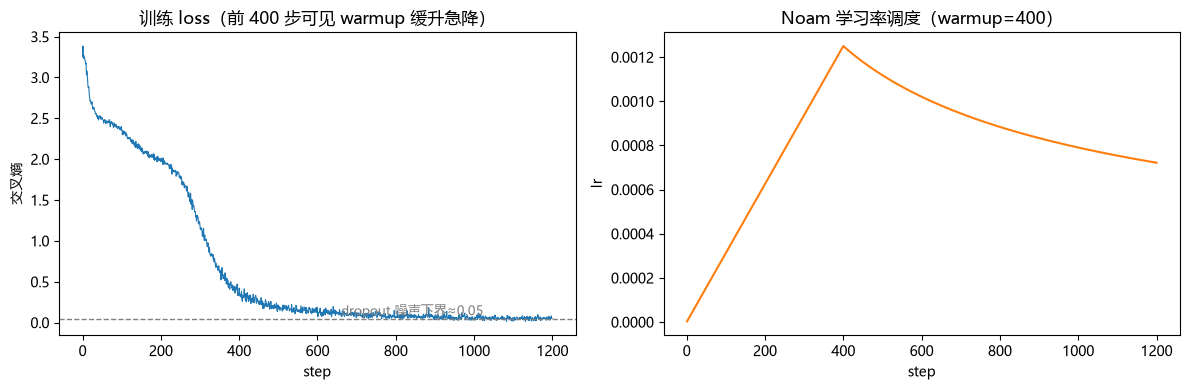

In [42]:
# ============ 可视化：loss 曲线与 Noam 学习率曲线 ============
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Micro Hei',
                                          'Microsoft YaHei', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses, lw=0.8)
axes[0].axhline(0.05, color='gray', ls='--', lw=1)
axes[0].text(len(losses)*0.55, 0.09, 'dropout 噪声下界≈0.05', color='gray', fontsize=9)
axes[0].set_title('训练 loss（前 400 步可见 warmup 缓升急降）')
axes[0].set_xlabel('step'); axes[0].set_ylabel('交叉熵')

steps = range(1, len(losses) + 1)
axes[1].plot(steps, [noam_lr(s) for s in steps], color='tab:orange')
axes[1].set_title('Noam 学习率调度（warmup=400）')
axes[1].set_xlabel('step'); axes[1].set_ylabel('lr')
plt.tight_layout(); plt.show()

## 第 12 章 · 总结与展望

12 章走完，回顾整张知识地图：

| 章 | 模块 | 一句话要点 |
|---|---|---|
| 1 | Embedding | 可训练查表矩阵 $\mathbf{E}\in\mathbb{R}^{V\times d}$，等价 one-hot × E |
| 2 | 位置编码 | sin/cos 多频率"时钟"，register_buffer 不可训练 |
| 3 | 注意力核心 | 稳定 softmax + $\sqrt{d_k}$ 缩放 + padding/causal mask |
| 4 | 多头注意力 | d_model 切 H 份并行算注意力，concat 后投影回原维度 |
| 5 | FFN | 逐位置两层 MLP（d→4d→d），事实知识主要存这里 |
| 6 | LayerNorm | 每 token 独立标准化，γ/β 可学习 |
| 7 | 残差连接 | $y = x + F(x)$，梯度恒等直通，24 层实验可复现 |
| 8 | 编码器 | 自注意力 + FFN，padding mask，Post-LN / Pre-LN |
| 9 | 解码器 | 掩码自注意力 + 交叉注意力 + FFN 三段式 |
| 10 | 总装 | encode/decode 拆分，src_mask 一份两用，Xavier 初始化 |
| 11 | 实战 | 教师强制训练、Noam warmup、贪心自回归解码 |

**验证结果**：手写模块与 PyTorch 官方实现逐一对照（Embedding / softmax / SDPA / MHA / LayerNorm / EncoderLayer / DecoderLayer），数值误差都在 1e-7 量级；复制任务 loss 收敛、贪心解码 exact match 100%。

**下一步可以做什么：**

1. **换真任务**：把复制任务换成翻译数据集（如 IWSLT），加 BPE 分词。
2. **结构变体**：实例化时传 `norm_first=True` 体验 Pre-LN（GPT-2 风格，深层更稳）。
3. **解码升级**：把贪心解码换成 beam search 或 top-k / top-p 采样。
4. **通往 GPT**：去掉编码器与交叉注意力，只堆"掩码自注意力 + FFN"（Pre-LN），就是 decoder-only 语言模型（GPT 系列）；只留编码器就是 BERT。
5. **推理优化**：KV cache——贪心解码时缓存历史 K/V，避免每步重算整个前缀。